In [1]:
import numpy as np
import matplotlib.pyplot as plt


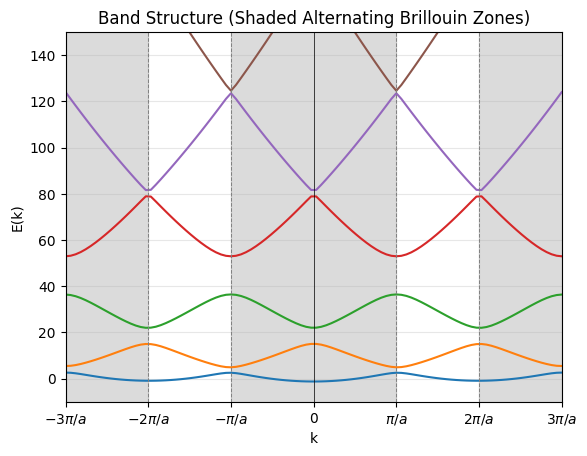

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
a = 1
h = 1
m = 1

V = [8,4,2,0,2,4,8]  # V(G) values for G = -3, -2, -1, 0, 1, 2, 3

def create_Hk(k, V):
    n = (len(V)-1)//2
    G_vals = np.array([2*np.pi*i/a for i in range(-n, n+1)])

    # kinetic term
    p = [h**2 * (k + G)**2 / (2*m) for G in G_vals]
    H = np.diag(p)

    # potential term
    for i in range(2*n + 1):
        for j in range(2*n + 1):
            diff = i - j
            if -n <= diff <= n:
                H[i, j] += V[diff + n]

    return H

def plot_band_structure():
    k_range = np.linspace(-3*np.pi/a, 3*np.pi/a, N)
    
    n = (len(V)-1)//2
    dim = 2*n + 1

    # Storing the eigenvalues
    bands = [[] for _ in range(dim)]

    for k in k_range:
        H_k = create_Hk(k, V)
        eigenvalues = np.linalg.eigvalsh(H_k)
        for i in range(dim):
            bands[i].append(eigenvalues[i])


    #shading BZ's
    bz_edges = np.arange(-3*np.pi/a, 4*np.pi/a, np.pi/a)
    bz_edges = bz_edges[bz_edges != 0]


    for i in range(len(bz_edges)-1):
        if i % 2 == 0:
            plt.axvspan(bz_edges[i], bz_edges[i+1], 
                        color='lightgray', alpha=0.8)

    for band in bands:
        plt.plot(k_range, band)

    for edge in bz_edges:
        plt.axvline(edge, linestyle='--', color='gray', linewidth=0.7)
        
    plt.axvline(0, linestyle='-', color='black', linewidth=0.5)

    plt.xlabel('k')
    plt.ylabel('E(k)')
    plt.title('Band Structure (Shaded Alternating Brillouin Zones)')
    plt.xlim(-3*np.pi/a, 3*np.pi/a)
    plt.ylim(-10,150)

    plt.xticks(
        np.arange(-3*np.pi/a, 4*np.pi/a, np.pi/a),
        [r'$-3\pi/a$', r'$-2\pi/a$', r'$-\pi/a$', '0', r'$\pi/a$', r'$2\pi/a$', r'$3\pi/a$']
    )
    
    plt.grid(alpha=0.3)
    plt.show()

plot_band_structure()